# Post-processing and standard plots

This tutorial introduces the standardized post-processing interface. We run a small Vlasov–Ampère example, get its output as an autocomplete-friendly `Output`, and make the plots most commonly used to inspect a simulation.

For a production run you can skip the simulation setup and open its output folder with `struphy.Output("path/to/sim")` instead.

In [1]:
import os
import tempfile

from IPython.display import HTML

from struphy import (
    BinningPlot,
    BoundaryParameters,
    ButcherTableau,
    DerhamOptions,
    EnvironmentOptions,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    equils,
    grids,
    maxwellians,
    perturbations,
)
from struphy.models import Maxwell, ViscousEulerSPH, VlasovAmpereOneSpecies

## Create a compact demonstration run

Post-processing operates on a completed run. The small setup below saves an electric field, a few marker trajectories, scalar diagnostics, and a binned $(\eta_1,v_1)$ distribution. These are the main output types handled by the plotting interface.

In [2]:
def build_model():
    model = VlasovAmpereOneSpecies(alpha=1.0, epsilon=-1.0, with_B0=False)
    model.em_fields.e_field.save_data = True
    model.em_fields.phi.save_data = True
    model.kinetic_ions.var.save_data = True

    model.propagators.push_eta.options = model.propagators.push_eta.Options()
    model.propagators.coupling_va.options = model.propagators.coupling_va.Options()
    model.initial_poisson.options = model.initial_poisson.Options(stab_mat="M0")

    binplot = BinningPlot(
        slice="e1_v1",
        n_bins=(32, 32),
        ranges=((0.0, 1.0), (-5.0, 5.0)),
    )
    model.kinetic_ions.set_markers(
        loading_params=LoadingParameters(ppc=32, seed=1234),
        weights_params=WeightsParameters(control_variate=True),
        boundary_params=BoundaryParameters(),
        sorting_params=SortingParameters(boxes_per_dim=(4, 1, 1), do_sort=True),
        saving_params=SavingParameters(n_markers=12, binning_plots=(binplot,)),
    )

    background = maxwellians.Maxwellian3D(n=(1.0, None))
    model.kinetic_ions.var.add_background(background)
    density_mode = perturbations.ModesCos(ls=(1,), amps=(1e-3,))
    model.kinetic_ions.var.add_initial_condition(maxwellians.Maxwellian3D(n=(1.0, density_mode)))

    return model


model = build_model()

/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:191: UserWarning: Override equation parameter self.alpha =1.0
  warnings.warn(f"Override equation parameter {self.alpha =}")
/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =-1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")


In [3]:
demo_tmp = tempfile.TemporaryDirectory(prefix="struphy_postprocessing_")
demo_root = demo_tmp.name

env = EnvironmentOptions(
    out_folders=demo_root,
    sim_folder="vlasov_ampere_demo",
    save_restart=False,
)
sim = Simulation(
    model=model,
    env=env,
    time_opts=Time(dt=0.05, Tend=5.0),
    domain=domains.Cuboid(r1=2 * 3.141592653589793),
    equil=equils.HomogenSlab(),
    grid=grids.TensorProductGrid(num_elements=(16, 1, 1)),
    derham_opts=DerhamOptions(degree=(2, 1, 1)),
)
out = sim.run()
print(f"Raw output: {sim.env.path_out}")

Stabilizing Poisson solve with self.options.sigma_1 =1e-14


Time stepping: 100%|██████████| 100/100 [00:22<00:00,  4.40step/s]
Raw output: /var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo


## Process and load the output

`sim.run()` returns the run's output as a `Output`, which is also available later as `sim.output`. Scalars are read directly from the raw output; fields and particle products need post-processing, which runs with default options the first time they are accessed.

To choose options, call `out.process()` first. It evaluates saved FEEC fields and organizes particle diagnostics; `physical=True` additionally creates physical field components. Existing products made with the same options are reused, so re-running a cell is cheap.

Individual products are standard `xarray.DataArray` objects with named dimensions, coordinates, units, and labels. Time is in Struphy units, in which the models' analytic results are written; seconds come along as the coordinate `t_seconds`, and `struphy.Output(path, time_units="physical")` makes `t` itself seconds. Arrays are loaded only when accessed. The saved configuration is available through `out.domain`, `out.model`, and `out.time_opts`; no simulation object is created.

In [4]:
out.process(physical=True)

/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:191: UserWarning: Override equation parameter self.alpha =1.0
  warnings.warn(f"Override equation parameter {self.alpha =}")
/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =-1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")

Post-processing path /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo

Reading hdf5 data of following species:
em_fields:
  e_field: <HDF5 group "/feec/em_fields/e_field" (3 members)>
  phi: <HDF5 dataset "phi": shape (101, 20, 3, 3), type "<f8">
Creation of Struphy Fields done.

Evaluating fields ...


100%|██████████| 101/101 [00:00<00:00, 146.08it/s]


Evaluation of 12 marker orbits for kinetic_ions


100%|██████████| 101/101 [00:00<00:00, 1306.96it/s]

Evaluation of distribution functions for kinetic_ions



0 starting post-processing of distribution functions for /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo/post_processing/kinetic_data/kinetic_ions ...
  0%|          | 0/1 [00:00<?, ?it/s]rank = 0 ----------------------------
self.rank =0 with xp.sum(data) =np.float64(10342.800145647723) and xp.sum(data_df) =np.float64(102.71735405419432)
self.rank =0 with xp.sum(data) =np.float64(10342.800145647723) and xp.sum(data_df) =np.float64(102.71735405419432)
self.rank =0 done.
100%|██████████| 1/1 [00:00<00:00, 46.30it/s]


Output('/private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo', processed=True)

Products sit on the run under the species that produced them, so VS Code and interactive shells complete them as you type: `out.kinetic_ions.e1_v1_density.f`, `out.kinetic_ions.orbits`, `out.em_fields.phi_log`. To discover the products a particular namespace contains, evaluate it or inspect its flat, lazy `.catalog`: `list(out.kinetic_ions.catalog)`. The grouped views `out.fields`, `out.distributions`, `out.densities` and `out.orbits` show the same products by kind, and `out["kinetic_ions/e1_v1_density/f"]` looks one up by name, which is handy in scripts and loops.

In [5]:
print(out.info())
print(out.kinetic_ions)

phase_space = out.kinetic_ions.e1_v1_density.f
print(phase_space)

Output of /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo
  dt=0.05, algo=LieTrotter, Nel=(16, 1, 1), p=(2, 1, 1)

scalars (no post-processing needed)
  out.scalars.electric_energy
  out.scalars.kinetic_energy
  out.scalars.total_energy

fields
  out.em_fields.e_field
  out.em_fields.e_field_xyz
  out.em_fields.phi
  out.em_fields.phi_xyz

distributions
  out.kinetic_ions.e1_v1_density.f  ($f$)
  out.kinetic_ions.e1_v1_density.delta_f  ($\delta f$)

densities
  (none)

orbits
  out.kinetic_ions.orbits
ProductNamespace('kinetic_ions', products=('e1_v1_density/delta_f', 'e1_v1_density/f', 'orbits'))
<xarray.DataArray 'f' (t: 101, e1: 32, v1: 32)> Size: 827kB
[103424 values with dtype=float64]
Coordinates:
  * t          (t) float64 808B 0.0 0.05 0.1 0.15 0.2 ... 4.8 4.85 4.9 4.95 5.0
    t_seconds  (t) float64 808B 0.0 1.668e-10 3.336e-10 ... 1.651e-08 1.668e-08
  * e1         (e1) float64 256B 0.01562 0.04688 0.07812 ... 0.9531

### Inspecting `out` itself

Most of what `out` exposes is generated on demand (`__getattr__`, cached properties), so `vars(out)` only shows a handful of private cache slots, not the products or methods. Use `dir(out)` for the flat list IPython's own tab-completion relies on, and `out.info()` for the full product tree. The same applies one level down: `out.model` is not a generic stub but the concrete model class of the run (`VlasovAmpereOneSpecies` here), so `dir(out.model)` and `print(out.model)` already show that model's own parameters directly — no separate `OutputVlasovAmpereOneSpecies`-style class is needed.

In [6]:
print("vars(out):", vars(out))  # only private cache slots
print()
print("dir(out):", [name for name in dir(out) if not name.startswith("_")])
print()
print(out.model)  # the concrete model class, with its own parameters
print("dir(out.model):", [name for name in dir(out.model) if not name.startswith("_")][:15])

vars(out): {'path_out': PosixPath('/private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/vlasov_ampere_demo'), 'time_units': 'normalized', 'comm': <mpi4py.MPI.Intracomm object at 0x11189cc00>, '_time': None, '_grids_log': None, '_grids_phy': None, '_scalars': <xarray.Dataset> Size: 4kB
Dimensions:          (t: 101)
Coordinates:
  * t                (t) float64 808B 0.0 0.05 0.1 0.15 ... 4.85 4.9 4.95 5.0
    t_seconds        (t) float64 808B 0.0 1.668e-10 ... 1.651e-08 1.668e-08
Data variables:
    electric_energy  (t) float64 808B 1.662e-06 1.651e-06 ... 1.488e-07
    kinetic_energy   (t) float64 808B 0.01887 0.01887 ... 0.01887 0.01887
    total_energy     (t) float64 808B 0.01887 0.01887 ... 0.01887 0.01887, '_products': {'fields': <struphy.post_processing.output.ProductMapping object at 0x139b51fd0>, 'distributions': <struphy.post_processing.output.ProductMapping object at 0x139b7c190>, 'densities': <struphy.post_processing.output.ProductMapping o

### Products are xarray arrays

A product is an `xarray.DataArray`, so xarray's own plotting already draws it, with the labels and units Struphy stored:

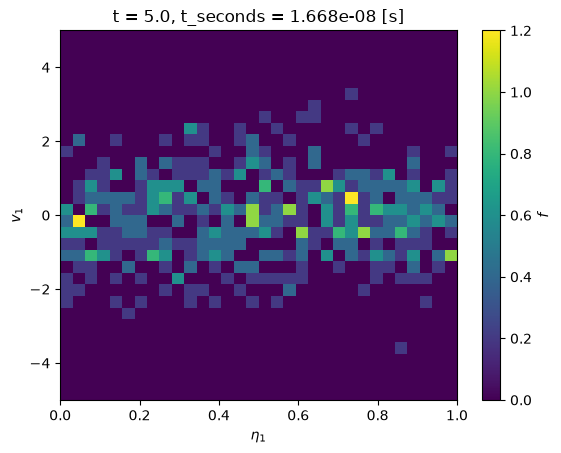

In [7]:
phase_space.isel(t=-1).plot(x="e1", y="v1")

Use `.struphy.plot` when xarray has nothing to offer: physical coordinates on a mapped domain, panels, the slider viewer, animations, growth-rate fits, and selections like `t="last"`. Everything below shows those.

## Scalar overview and time series

Products plot themselves: every array has a `.struphy` accessor holding `.plot` and `.analysis`, so `out.kinetic_ions.e1_v1_density.f.struphy.plot.slice(...)` needs no imports and completes as you type. `out["kinetic_ions/e1_v1_density/f"]` looks the same product up by name, which suits scripts and loops. The plots that need a whole run, `out.plot.scalars()` and `out.plot.equilibrium()`, stay on the run.

`out.plot.scalars()` gives a quick overview of every recorded scalar. `.struphy.plot.timeseries()` shows individual series on linear or logarithmic axes; `fit=(t0, t1)` adds an exponential fit restricted to that time window. Plots return an already-rendered `PlotResult`, which a notebook displays by itself; calling `.save()` never draws a second figure.

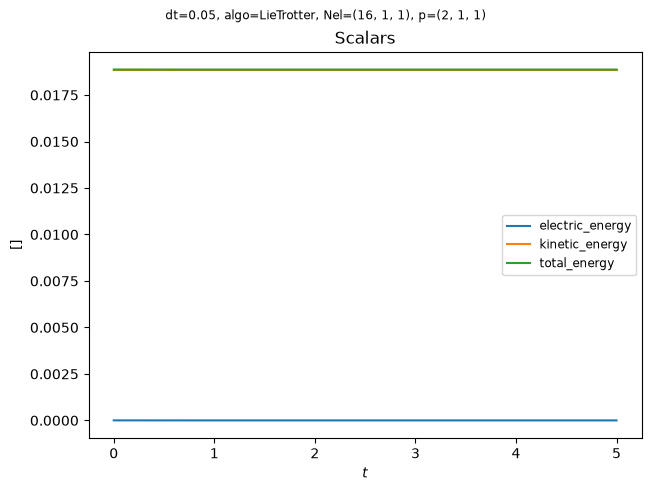

In [8]:
out.plot.scalars()

growth rate of the energy: -1.3534170635343759
growth rate of the amplitude: -0.6767085317671879


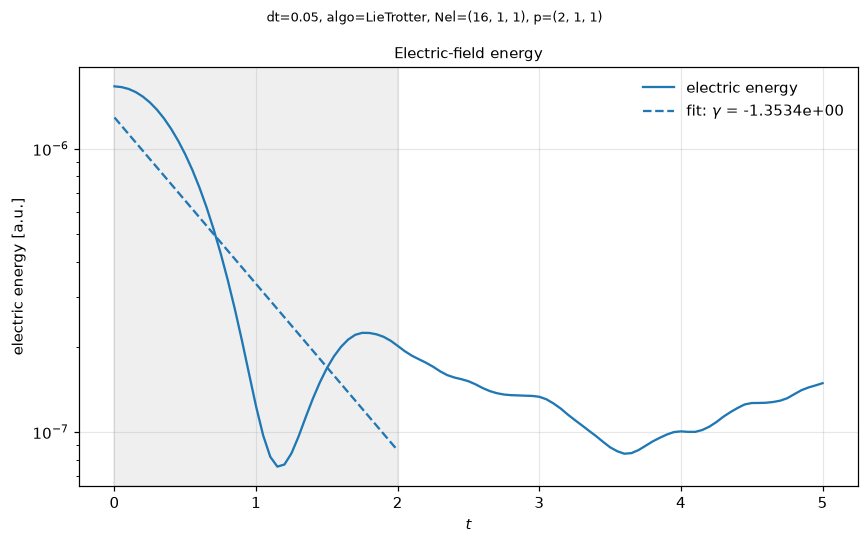

In [9]:
t_fit = 2.0  # Struphy time units, like every time coordinate of this run
energy_plot = out.scalars.electric_energy.struphy.plot.timeseries(
    fit=(0.0, t_fit),
    #fit_amplitude=True,
    title="Electric-field energy",
)
print("growth rate of the energy:", energy_plot.fit_results[0].rate)

# the same fit without drawing; amplitude=True fits the amplitude of a quadratic quantity,
# so the rate comes out half as large for an energy
rate = out.scalars.electric_energy.struphy.analysis.growth_rate(window=(0.0, t_fit), amplitude=True).rate
print("growth rate of the amplitude:", rate)

## Two-dimensional data

Choose the displayed dimensions with `x` and `y`, and pick one value for every other dimension by naming it: `t="last"` (or `"first"`), `t=-1` for a position, and `t=0.35` for the nearest coordinate value. Arrays can also be sliced beforehand with xarray's `.isel()` and `.sel()`. `coords="physical"` draws on the mapped coordinates instead of the logical ones.

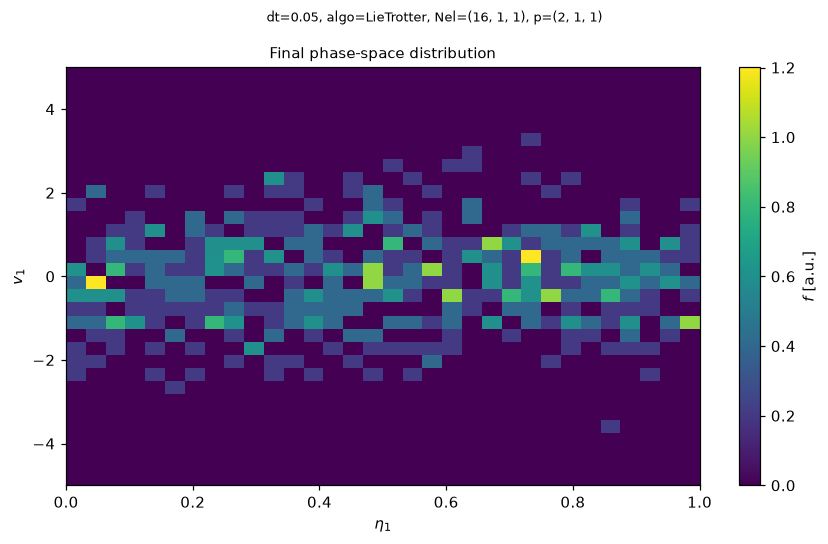

In [10]:
phase_space.struphy.plot.slice(
    x="e1",
    y="v1",
    t="last",
    equal_aspect=False,
    title="Final phase-space distribution",
)

For a compact view of the evolution, `.struphy.plot.panels()` chooses evenly spaced snapshots in time. `shared_clim=True` makes panel colors directly comparable.

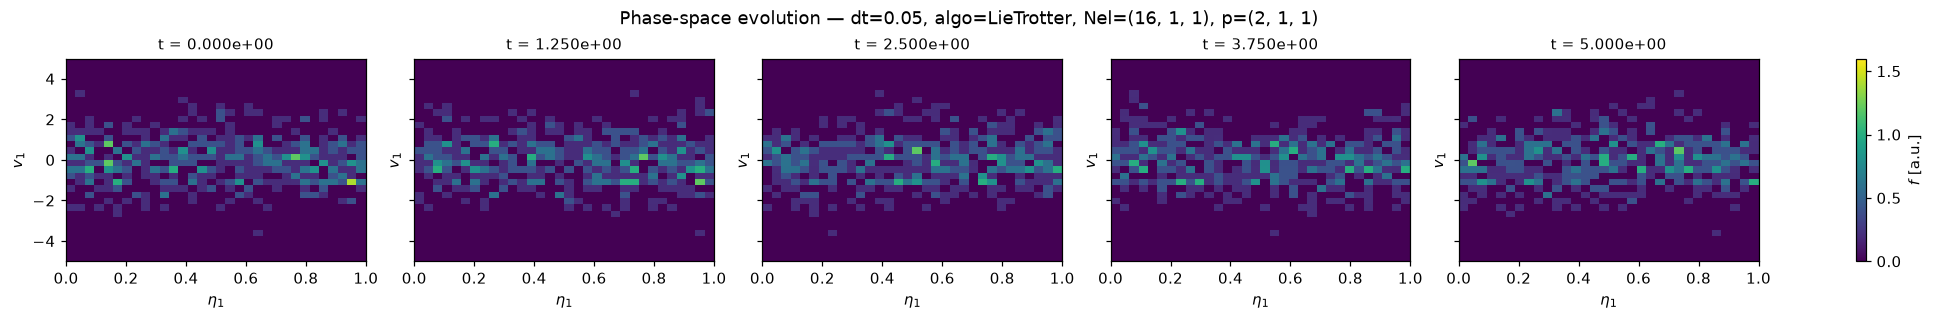

In [11]:
phase_space.struphy.plot.panels(
    x="e1",
    y="v1",
    nrows=1,
    ncols=5,
    title="Phase-space evolution",
)

## Interactive plots

`.struphy.plot.viewer()` adds one slider for every dimension not assigned to the display axes. In JupyterLab, run `%matplotlib widget` before this cell if `ipympl` is installed; the default inline backend still displays the initial frame. Keep the viewer alive so its callbacks remain connected. `out.plot.animation()` and `out.plot.frames()` sweep the same way.

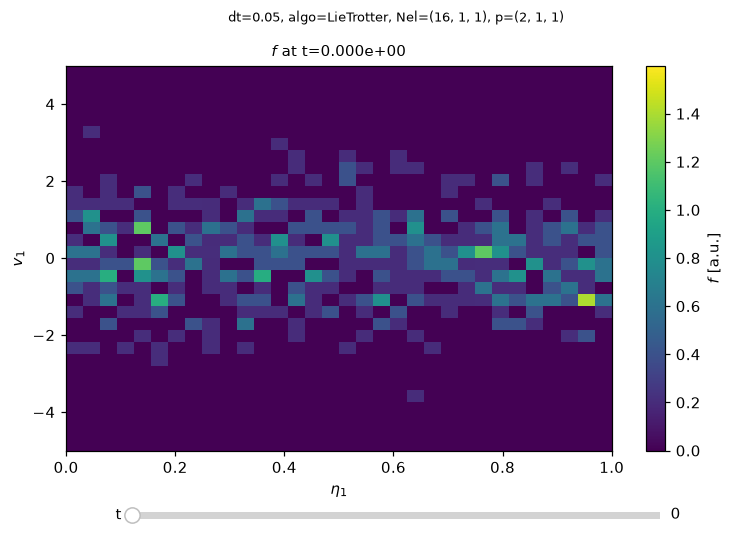

In [12]:
phase_viewer = phase_space.struphy.plot.viewer(x="e1", y="v1")
phase_viewer

Saved marker orbits sit under their species. `.struphy.plot.trajectories()` draws their three-dimensional paths, while `max_markers` limits rendering cost for large production runs.

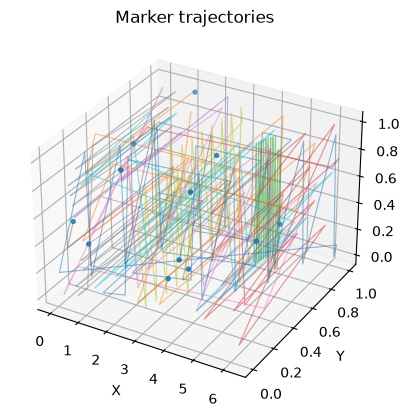

In [13]:
out.kinetic_ions.orbits.struphy.plot.trajectories(max_markers=12, show_paths=True)

`.struphy.plot.animation()` and `.struphy.plot.frames()` sweep the same data as the viewer. The animation is a Matplotlib `FuncAnimation`, displayed here as JavaScript; `frames()` writes one PNG per step and returns the paths.

In [14]:
animation = phase_space.struphy.plot.animation(x="e1", y="v1", step=4)
HTML(animation.to_jshtml())

In [15]:
frames = phase_space.struphy.plot.frames(os.path.join(demo_root, "frames"), x="e1", y="v1", step=10)
print("Wrote:", [os.path.basename(path) for path in frames])

Wrote: ['frame_0000.png', 'frame_0001.png', 'frame_0002.png', 'frame_0003.png', 'frame_0004.png', 'frame_0005.png', 'frame_0006.png', 'frame_0007.png', 'frame_0008.png', 'frame_0009.png', 'frame_0010.png']


For a run with a fluid equilibrium, `out.plot.equilibrium()` plots its radial profiles; it needs the run rather than a single array, like `out.plot.scalars()` and `out.save_report()`.

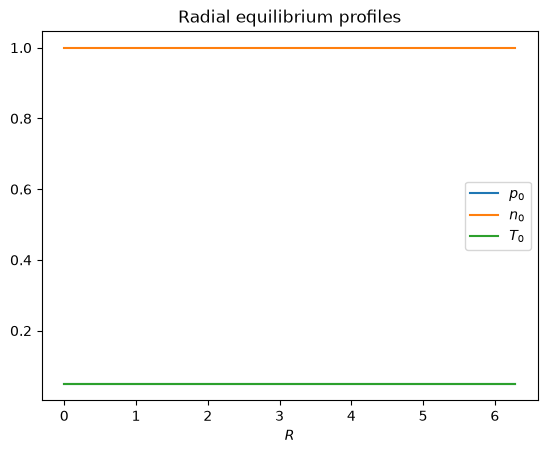

In [16]:
out.plot.equilibrium()

## Derived quantities

`.struphy.analysis` computes without drawing, and every result is an array that plots itself. `drift()` subtracts the first sample, `relative_error()` gives the deviation relative to it, which is the usual way to inspect energy conservation.

largest drift of the total energy: 1.586e-06


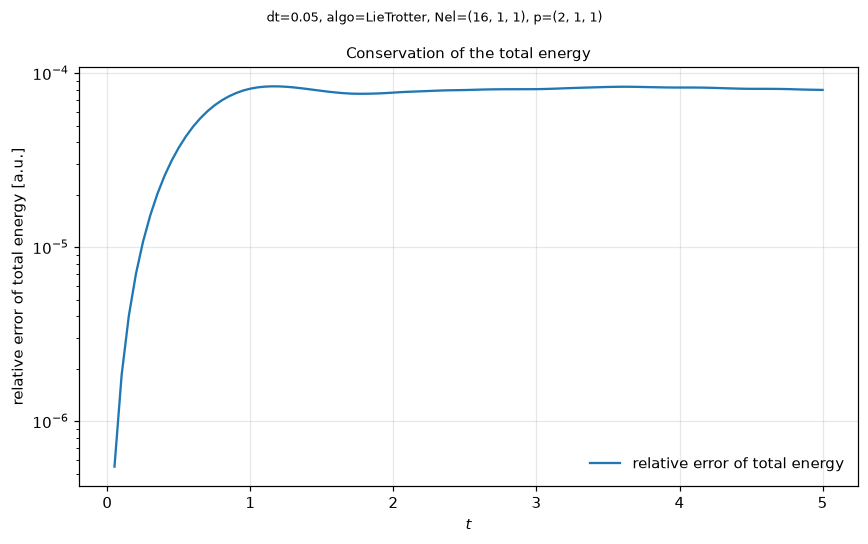

In [17]:
total_energy = out.scalars.total_energy
energy_error = total_energy.struphy.analysis.relative_error()
energy_drift = total_energy.struphy.analysis.drift()
print(f"largest drift of the total energy: {abs(energy_drift).max().item():.3e}")

energy_error.struphy.plot.timeseries(title="Conservation of the total energy")

`.struphy.analysis.dispersion()` takes the space-time Fourier transform of a field along one direction and draws the spectrum. `slice_at` picks the direction of the transform (`None`) and the indices of the other two. Pass `disp_name` to overlay an analytic dispersion relation from `struphy.dispersion_relations.analytic`, and `fit_branches` to fit the dominant branches.

/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/diagnostics/diagn_tools.py:246: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


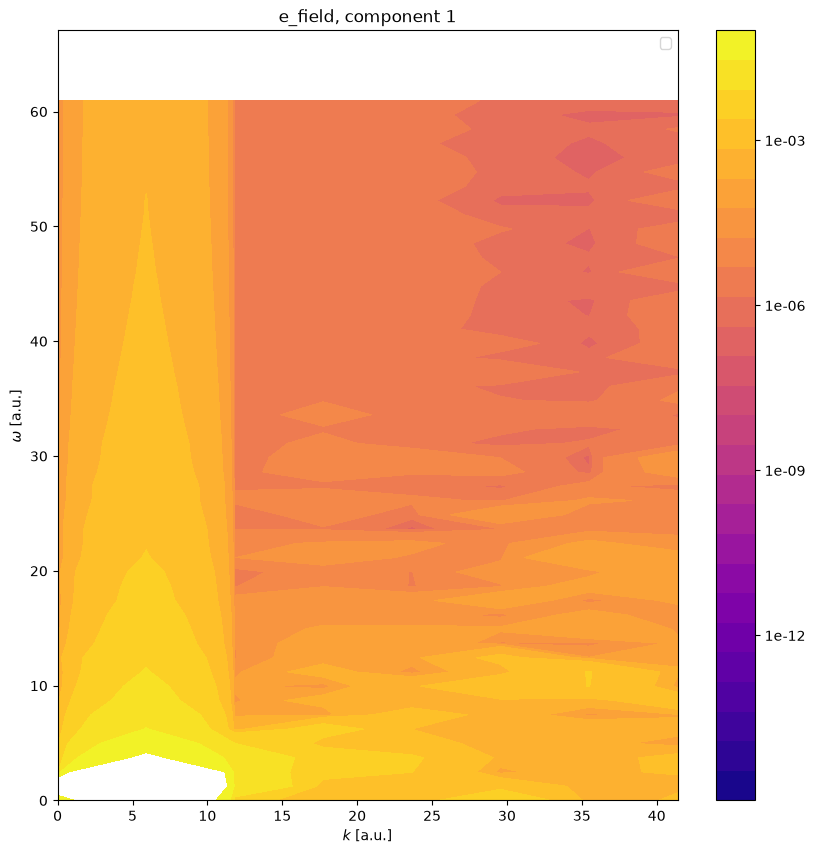

spectrum: (50, 8)


In [18]:
omega, kvec, spectrum, _ = out.em_fields.e_field.struphy.analysis.dispersion(
    slice_at=(None, 0, 0),
    do_plot=True,
)
print("spectrum:", spectrum.shape)

## Save standard output

Every `PlotResult` supports `.save(path)`. For a complete scalar report, `out.save_report()` writes a CSV table, an overview, and one PNG per scalar beneath `post_processing/report/`.

In [19]:
written = out.save_report()
print("Wrote:")
for path in written:
    print(" ", os.path.relpath(path, out.path_out))

Wrote:
  post_processing/report/scalars.csv
  post_processing/report/scalars.png
  post_processing/report/electric_energy.png
  post_processing/report/kinetic_energy.png
  post_processing/report/total_energy.png


## Comparing runs

Time series accept arrays of other simulations, so comparing runs needs nothing special. Series are labelled by the run they come from, and the runs may have different time grids.

/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:191: UserWarning: Override equation parameter self.alpha =1.0
  warnings.warn(f"Override equation parameter {self.alpha =}")
/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =-1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")
Stabilizing Poisson solve with self.options.sigma_1 =1e-14


Time stepping: 100%|██████████| 20/20 [00:04<00:00,  4.38step/s]


/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:191: UserWarning: Override equation parameter self.alpha =1.0
  warnings.warn(f"Override equation parameter {self.alpha =}")
/Users/max/git_repos/struphy-hub.github.io/submodules/struphy/src/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =-1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")


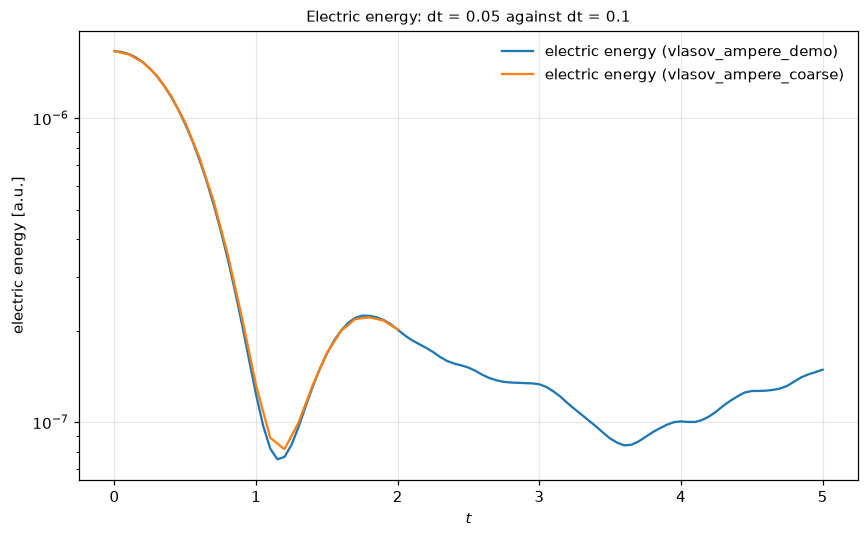

In [ ]:
sim_coarse = Simulation(
    model=build_model(),
    env=EnvironmentOptions(out_folders=demo_root, sim_folder="vlasov_ampere_coarse", save_restart=False),
    time_opts=Time(dt=0.1, Tend=5.0),
    domain=domains.Cuboid(r1=2 * 3.141592653589793),
    equil=equils.HomogenSlab(),
    grid=grids.TensorProductGrid(num_elements=(16, 1, 1)),
    derham_opts=DerhamOptions(degree=(2, 1, 1)),
)
out_coarse = sim_coarse.run()

out.scalars.electric_energy.struphy.plot.timeseries(
    out_coarse.scalars.electric_energy,
    title="Electric energy: dt = 0.05 against dt = 0.1",
)

## Other models

The interface is the same for every model; only the products differ. Two more short runs show the two product types the Vlasov–Ampère demo does not have: SPH densities, and vector fields on a mapped domain.

### SPH densities

A standing sound wave discretized with SPH markers. `KernelDensityPlot` reconstructs the density on a grid, which appears under `out.densities`, while `BinningPlot` produces the binned quantities under `out.distributions`.

In [21]:
sph_model = ViscousEulerSPH(with_B0=False, with_viscosity=False)
sph_model.propagators.push_eta.options = sph_model.propagators.push_eta.Options(
    butcher=ButcherTableau(algo="forward_euler"),
)
sph_model.propagators.push_sph_p.options = sph_model.propagators.push_sph_p.Options(kernel_type="gaussian_1d")
sph_model.euler_fluid.set_markers(
    loading_params=LoadingParameters(ppb=8, loading="tesselation"),
    weights_params=WeightsParameters(),
    boundary_params=BoundaryParameters(),
    sorting_params=SortingParameters(boxes_per_dim=(12, 1, 1), dims_mask=(True, False, False)),
    saving_params=SavingParameters(
        binning_plots=(BinningPlot(slice="e1", n_bins=(32,), ranges=(0.0, 1.0)),),
        kernel_density_plots=(KernelDensityPlot(pts_e1=41, pts_e2=1),),
    ),
)
sph_model.euler_fluid.var.add_background(equils.ConstantVelocity())
sph_model.euler_fluid.var.add_perturbation(del_n=perturbations.ModesSin(ls=(1,), amps=(1.0e-2,)))

sph = Simulation(
    model=sph_model,
    env=EnvironmentOptions(out_folders=demo_root, sim_folder="sph_soundwave", save_restart=False),
    time_opts=Time(dt=0.03125, Tend=2.5, split_algo="Strang"),
    domain=domains.Cuboid(r1=2.5),
    grid=None,
    derham_opts=None,
)
out_sph = sph.run()

print("densities:", tuple(out_sph.density_catalog))
print("binned:", tuple(out_sph.distribution_catalog))

Time stepping: 100%|██████████| 80/80 [00:01<00:00, 43.56step/s]


No post-processed data in /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/sph_soundwave, processing with default options (call out.process(...) to choose them)

Post-processing path /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/sph_soundwave

No feec fields found in hdf5 file, skipping post-processing of fields.
Evaluation of 3 marker orbits for euler_fluid



100%|██████████| 81/81 [00:00<00:00, 1169.69it/s]

Evaluation of distribution functions for euler_fluid



0 starting post-processing of distribution functions for /private/var/folders/41/knyv28q16gv84h05plqzft_00000gn/T/struphy_postprocessing_3aawuvfp/sph_soundwave/post_processing/kinetic_data/euler_fluid ...
  0%|          | 0/1 [00:00<?, ?it/s]rank = 0 ----------------------------
self.rank =0 with xp.sum(data) =np.float64(1036.8000000000002) and xp.sum(data_df) =np.float64(1036.8000000000002)
self.rank =0 with xp.sum(data) =np.float64(1036.8000000000002) and xp.sum(data_df) =np.float64(1036.8000000000002)
self.rank =0 done.
100%|██████████| 1/1 [00:00<00:00, 69.57it/s]

Evaluation of sph density for euler_fluid



100%|██████████| 1/1 [00:00<00:00, 48.08it/s]
densities: ('euler_fluid/view_0/n',)
binned: ('euler_fluid/e1_density/f', 'euler_fluid/e1_density/delta_f')


For a one-dimensional run, the clearest picture is a space-time map: the sweep dimension `t` may be used as a display axis.

In [22]:
density = out_sph.euler_fluid.view_0.n_sph.isel(e2=0, e3=0)
density.plot(x="t", y="e1")

AttributeError: 'n_sph'; available names under 'euler_fluid/view_0': ('n',)

Products are plain `xarray.DataArray` objects, so anything xarray can do works directly, for example profiles at selected times:

In [ ]:
density.isel(t=[0, len(density.t) // 4, len(density.t) // 2]).plot.line(x="e1")

### Vector fields on a mapped domain

A coaxial waveguide mode of the Maxwell model, on an annulus. With `physical=True` the post-processing also computes the Cartesian field components (`*_xyz`), and `coords="physical"` draws them on the mapped grid, with the plane chosen by `plane`.

In [ ]:
a1, a2 = 2.326744, 3.686839

maxwell_model = Maxwell()
maxwell_model.propagators.maxwell.options = maxwell_model.propagators.maxwell.Options(algo="implicit")
maxwell_model.em_fields.e_field.add_perturbation(perturbations.CoaxialWaveguideElectric_r(m=3, a1=a1, a2=a2))
maxwell_model.em_fields.e_field.add_perturbation(perturbations.CoaxialWaveguideElectric_theta(m=3, a1=a1, a2=a2))
maxwell_model.em_fields.b_field.add_perturbation(perturbations.CoaxialWaveguideMagnetic(m=3, a1=a1, a2=a2))

coaxial = Simulation(
    model=maxwell_model,
    env=EnvironmentOptions(out_folders=demo_root, sim_folder="coaxial", save_restart=False),
    time_opts=Time(dt=0.05, Tend=2.0),
    domain=domains.HollowCylinder(a1=a1, a2=a2, Lz=2.0),
    equil=equils.HomogenSlab(),
    grid=grids.TensorProductGrid(num_elements=(24, 48, 1)),
    derham_opts=DerhamOptions(degree=(2, 2, 1), bcs=(("dirichlet", "dirichlet"), None, None)),
)
out_coaxial = coaxial.run()
out_coaxial.process(physical=True)

print("fields:", tuple(out_coaxial.field_catalog))
print("dimensions:", out_coaxial.em_fields.b_field_xyz.dims)

In [ ]:
out_coaxial.em_fields.b_field_xyz.struphy.plot.slice(
    x="e1",
    y="e2",
    t="last",
    component=2,
    e3=0,
    coords="physical",
    plane="XY",
    title="$B_z$ of the coaxial mode",
)

In [ ]:
out_coaxial.em_fields.b_field_xyz.struphy.plot.panels(
    x="e1",
    y="e2",
    component=2,
    e3=0,
    coords="physical",
    plane="XY",
    nrows=1,
    ncols=4,
    title="$B_z$ over time",
)

## Apply the workflow to another run

For an already completed simulation, possibly in a separate process without MPI, open its output folder:

```python
import struphy

out = struphy.Output("/path/to/sim_1").process(physical=True)
out.domain, out.model.units  # reconstructed directly from saved metadata
```

Use `out.scalars`, `out.fields`, `out.distributions`, `out.orbits`, and `out.densities`. Attribute access is the normal interactive API; the corresponding `*_catalog` mappings are intended for generic loops and tooling.